In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [19]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df = df[df['job_title_short'] == 'Data Analyst']

In [29]:
# Way 1 to get the DF
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
df_skills_grouped = df_skills.groupby('job_skills')['salary_year_avg'].agg(['size', 'median'])
df_skills_grouped.sort_values(by='size', ascending=False).head(10)

,size,median
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


In [ ]:
# Way 2 to get the DF
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
df_skills_grouped = df_skills.groupby('job_skills').agg(
    skills_count = ('job_skills', 'count'), #cuenta las filas no nulas de job_skills
    median_salary = ('salary_year_avg', 'median') 
)
df_skills_sorted = df_skills_grouped.sort_values(by='skills_count', ascending=False).head(10)
df_skills_sorted

,skills_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


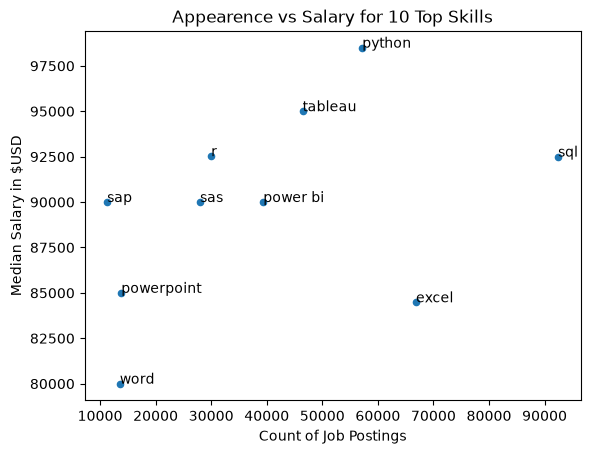

In [38]:
df_skills_sorted.plot(kind='scatter', x='skills_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary in $USD')
plt.title('Appearence vs Salary for 10 Top Skills')

for i, skill in enumerate(df_skills_sorted.index):
    plt.text(df_skills_sorted['skills_count'].iloc[i], df_skills_sorted['median_salary'].iloc[i], skill)

plt.show()